# Lab 2: Multi-Class Human Activity Recognition (HAR) and Model Quantization

**Aim:** Classify three activities (Idle, Walking, Sit-ups) from smartphone accelerometer data using a small neural network, then compare four TensorFlow Lite (TFLite) quantization schemes on model size, accuracy, and inference speed.

| Item | Value |
|---|---|
| Sensor | phyphox Linear Acceleration (x, y, z), 100 Hz |
| Recording used per class | First 20 seconds |
| Window | 1 second (100 samples), 50% overlap |
| Features | Mean, Standard Deviation (Std), Root Mean Square (RMS) of magnitude |
| Model | Multi-Layer Perceptron (MLP), 3 → 128 → 64 → 3 |
| Variants | Float32, Dynamic Range, Float16, Full Integer (int8) |

### Workflow
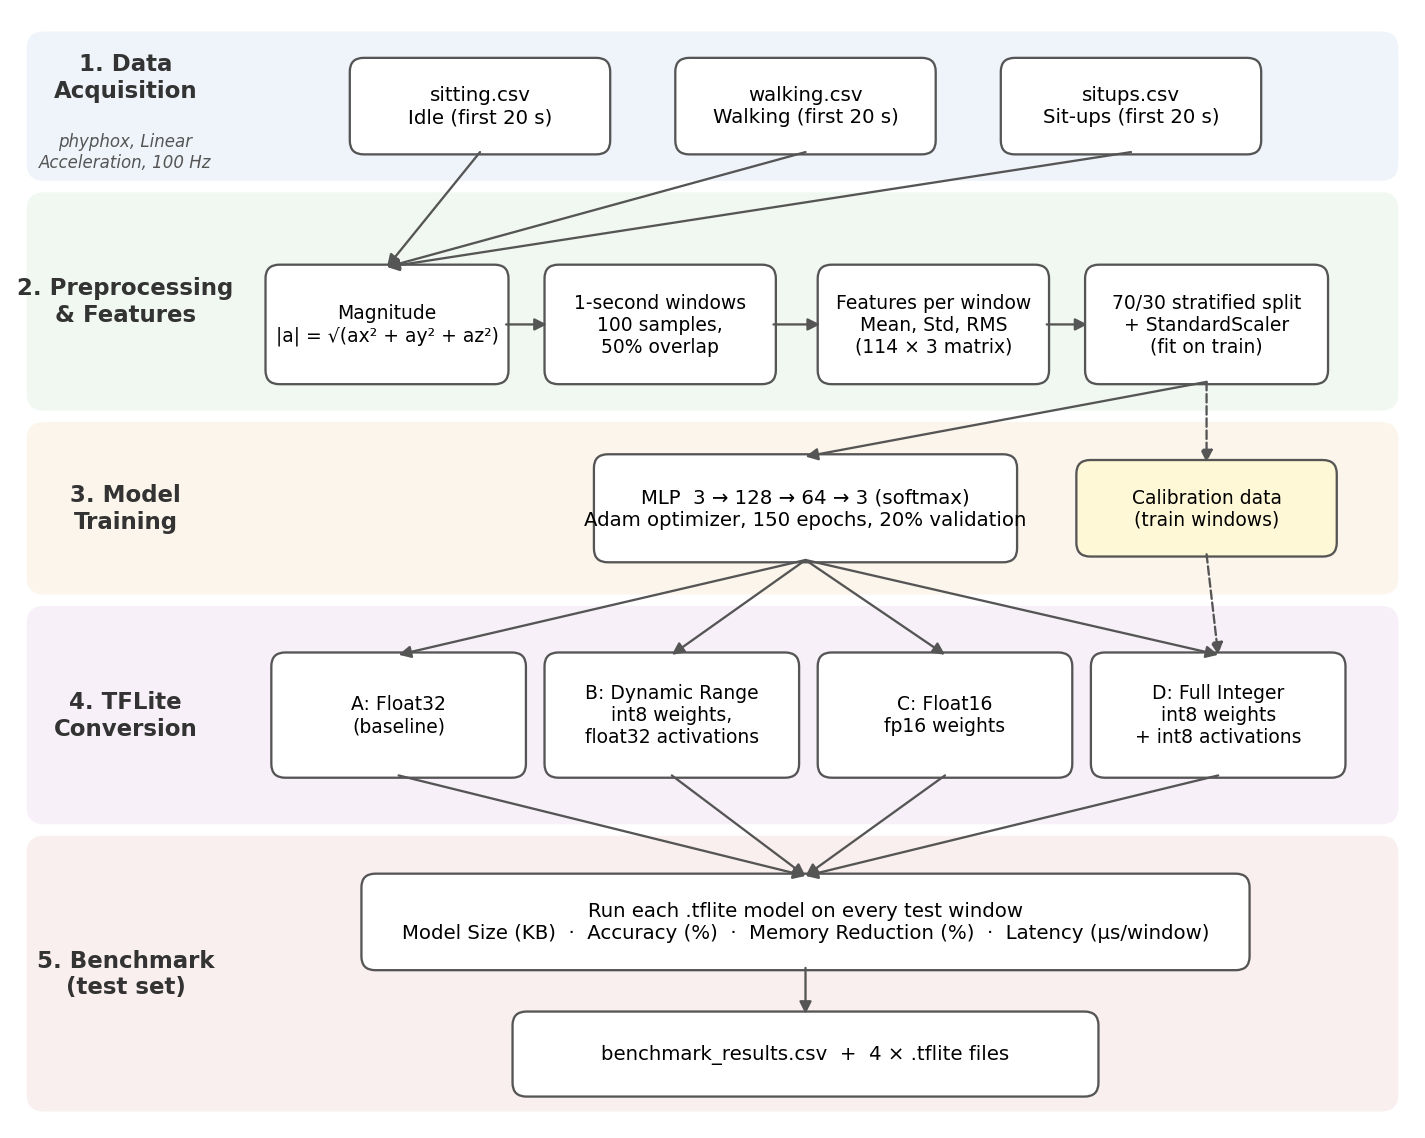

## 1. Setup
Install the required libraries (only needed once).

In [1]:
%pip install -q tensorflow pandas scikit-learn matplotlib jinja2

Note: you may need to restart the kernel to use updated packages.


Imports, configuration, and a helper to display tables neatly.

In [2]:
import os
import io
import time
import warnings
import contextlib
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")


@contextlib.contextmanager
def silence():
    """Hides TensorFlow's low-level log messages so the output stays clean."""
    saved = [os.dup(1), os.dup(2)]
    devnull = os.open(os.devnull, os.O_WRONLY)
    os.dup2(devnull, 1)
    os.dup2(devnull, 2)
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            yield
    finally:
        os.dup2(saved[0], 1)
        os.dup2(saved[1], 2)
        for fd in saved + [devnull]:
            os.close(fd)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
with silence():
    import tensorflow as tf
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

tf.get_logger().setLevel("ERROR")

DATA = {
    "Idle":    "/Users/Tanmay/Downloads/sitting still/sitting.csv",
    "Walking": "/Users/Tanmay/Downloads/walking/walking.csv",
    "Sit-ups": "/Users/Tanmay/Downloads/situps/situps.csv",
}
CLASSES = list(DATA.keys())
FS = 100
DURATION = 20
WINDOW = FS
STEP = FS // 2
OUT_DIR = "har_outputs"
COLORS = {"Idle": "#4C72B0", "Walking": "#55A868", "Sit-ups": "#C44E52"}

np.random.seed(42)
tf.random.set_seed(42)
os.makedirs(OUT_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})

TABLE_STYLE = [
    {"selector": "th", "props": "background-color:#2f4b7c; color:white; text-align:center; padding:6px 12px;"},
    {"selector": "td", "props": "text-align:center; padding:5px 12px;"},
]

def show(df, precision=2):
    display(df.style.hide(axis="index").format(precision=precision).set_table_styles(TABLE_STYLE))

## 2. Load Raw Data
Each recording is trimmed to its first 20 seconds so every class contributes the same amount of data.

In [3]:
raw, rows = {}, []
for name, path in DATA.items():
    df = pd.read_csv(path)
    df.columns = ["t", "ax", "ay", "az", "abs"]
    trimmed = df[df["t"] < DURATION].reset_index(drop=True)
    raw[name] = trimmed
    rows.append([name, os.path.basename(path), df["t"].iloc[-1], len(df),
                 len(trimmed), round(1 / df["t"].diff().median())])

show(pd.DataFrame(rows, columns=["Class", "File", "Recorded (s)", "Total Samples",
                                 "Samples Used (20 s)", "Sampling Rate (Hz)"]), precision=1)

Class,File,Recorded (s),Total Samples,Samples Used (20 s),Sampling Rate (Hz)
Idle,sitting.csv,21.8,2172,1997,100
Walking,walking.csv,21.5,2150,1997,100
Sit-ups,situps.csv,24.4,2437,1997,100


## 3. Acceleration Magnitude
The three axes are combined into one orientation-independent signal:

$$|a| = \sqrt{a_x^2 + a_y^2 + a_z^2}$$

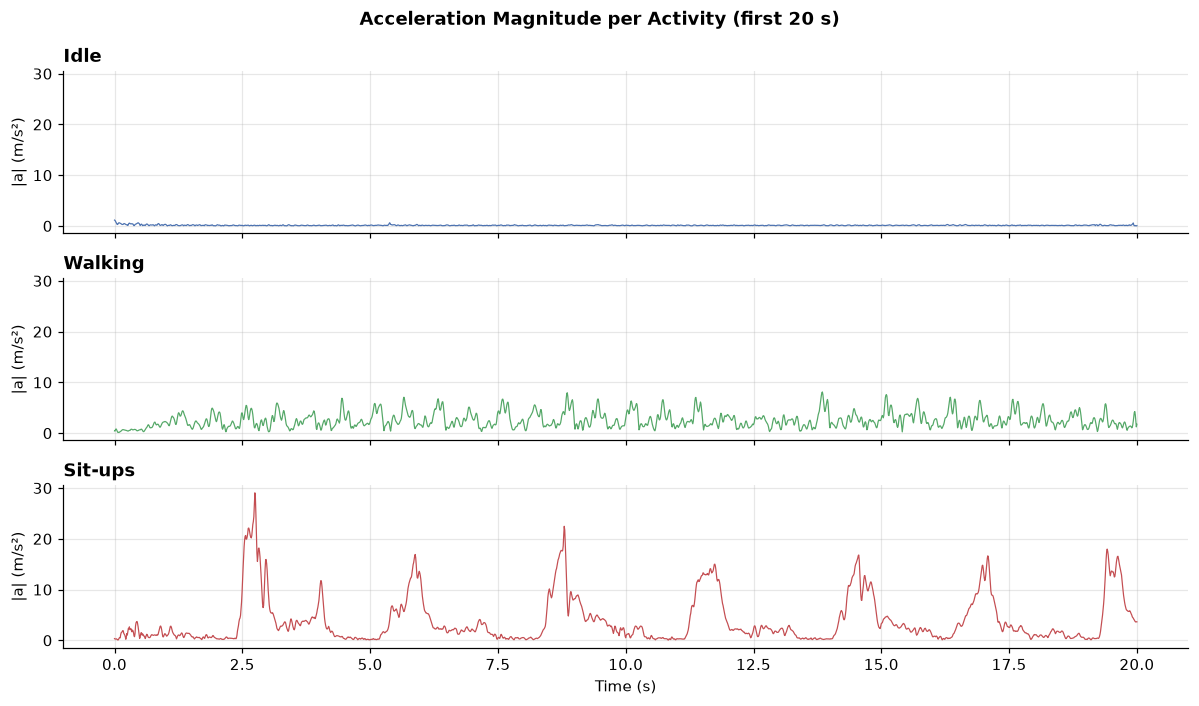

In [4]:
for df in raw.values():
    df["mag"] = np.sqrt(df["ax"]**2 + df["ay"]**2 + df["az"]**2)

fig, axes = plt.subplots(3, 1, figsize=(11, 6.5), sharex=True, sharey=True)
for ax, (name, df) in zip(axes, raw.items()):
    ax.plot(df["t"], df["mag"], color=COLORS[name], lw=0.8)
    ax.set_title(name, loc="left", weight="bold")
    ax.set_ylabel("|a| (m/s²)")
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Acceleration Magnitude per Activity (first 20 s)", weight="bold")
plt.tight_layout()
plt.show()

## 4. Windowing and Feature Extraction
The magnitude signal is split into 1-second windows (N = 100 samples) with 50% overlap. Three features are computed per window:

$$\mu = \frac{1}{N}\sum_{i=1}^{N}|a_i| \qquad \sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N}\left(|a_i| - \mu\right)^2} \qquad \text{RMS} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}|a_i|^2}$$

In [5]:
def extract_features(mag):
    feats = []
    for start in range(0, len(mag) - WINDOW + 1, STEP):
        w = mag[start:start + WINDOW]
        feats.append([w.mean(), w.std(), np.sqrt(np.mean(w**2))])
    return np.array(feats)

X_list, y_list = [], []
for label, name in enumerate(CLASSES):
    f = extract_features(raw[name]["mag"].to_numpy())
    X_list.append(f)
    y_list.append(np.full(len(f), label))

X = np.vstack(X_list).astype(np.float32)
y = np.concatenate(y_list)

features = pd.DataFrame(X, columns=["Mean", "Std", "RMS"])
features.insert(0, "Class", [CLASSES[i] for i in y])

print(f"Feature matrix: {X.shape[0]} windows x {X.shape[1]} features\n")
print("Average feature values per class:")
show(features.groupby("Class", sort=False)
     .agg(Windows=("Mean", "size"), Mean=("Mean", "mean"), Std=("Std", "mean"), RMS=("RMS", "mean"))
     .reset_index(), precision=3)

Feature matrix: 114 windows x 3 features

Average feature values per class:


Class,Windows,Mean,Std,RMS
Idle,38,0.121,0.054,0.133
Walking,38,2.620,1.390,2.970
Sit-ups,38,3.767,2.913,4.838


How well each feature separates the three classes:

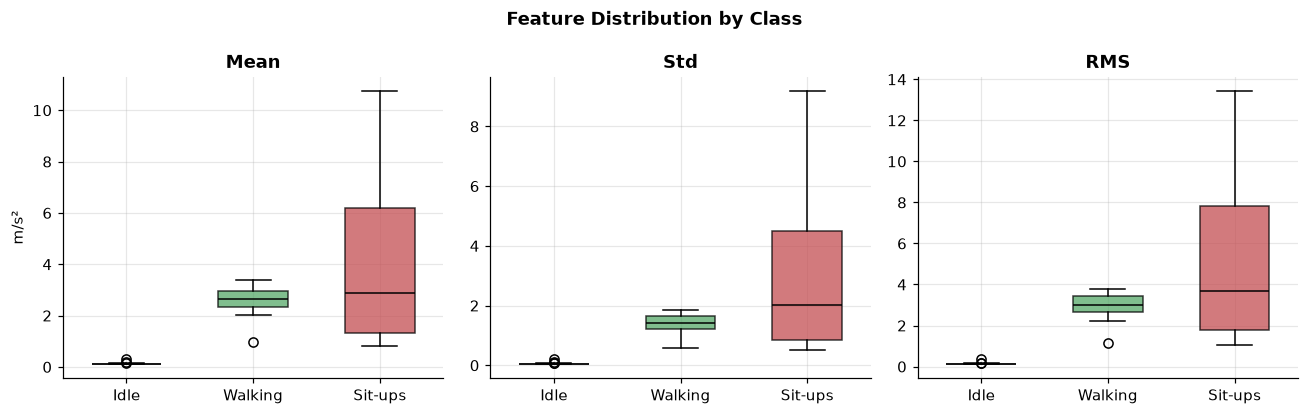

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, feat in zip(axes, ["Mean", "Std", "RMS"]):
    data = [features.loc[features["Class"] == c, feat] for c in CLASSES]
    bp = ax.boxplot(data, patch_artist=True, widths=0.55, medianprops={"color": "black"})
    for patch, c in zip(bp["boxes"], CLASSES):
        patch.set_facecolor(COLORS[c])
        patch.set_alpha(0.75)
    ax.set_xticks([1, 2, 3], CLASSES)
    ax.set_title(feat, weight="bold")
axes[0].set_ylabel("m/s²")
fig.suptitle("Feature Distribution by Class", weight="bold")
plt.tight_layout()
plt.show()

## 5. Train/Test Split and Normalization
Stratified 70/30 split so each class keeps the same proportion. `StandardScaler` is fit on the training set only, to avoid leaking test information.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

split = pd.DataFrame({"Class": CLASSES, "Train": np.bincount(y_train), "Test": np.bincount(y_test)})
split.loc[len(split)] = ["Total", len(y_train), len(y_test)]
show(split)

Class,Train,Test
Idle,27,11
Walking,26,12
Sit-ups,26,12
Total,79,35


## 6. Baseline Model (MLP)
### 6.1 Architecture

In [8]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(3,)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax"),
])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,963 (35.01 KB)

 Trainable params: 8,963 (35.01 KB)

 Non-trainable params: 0 (0.00 B)

### 6.2 Training
150 epochs with the Adam optimizer. 20% of the training set is held out for validation to monitor overfitting.

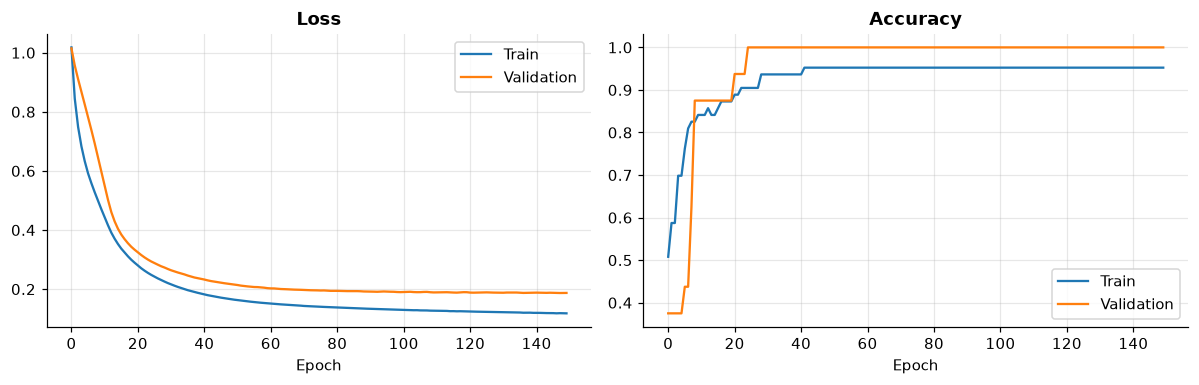

In [9]:
history = model.fit(X_train, y_train, validation_split=0.2, epochs=150, batch_size=8, verbose=0)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.plot(history.history["loss"], label="Train")
a1.plot(history.history["val_loss"], label="Validation")
a1.set_title("Loss", weight="bold")
a2.plot(history.history["accuracy"], label="Train")
a2.plot(history.history["val_accuracy"], label="Validation")
a2.set_title("Accuracy", weight="bold")
for a in (a1, a2):
    a.set_xlabel("Epoch")
    a.legend()
plt.tight_layout()
plt.show()

### 6.3 Baseline Evaluation on the Test Set

Baseline (Keras) test accuracy: 94.29%


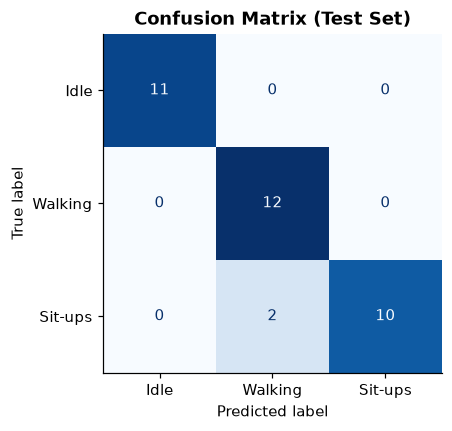

Class,Precision,Recall,F1-score,Support
Idle,1.00,1.00,1.00,11
Walking,0.86,1.00,0.92,12
Sit-ups,1.00,0.83,0.91,12


In [10]:
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
print(f"Baseline (Keras) test accuracy: {np.mean(y_pred == y_test) * 100:.2f}%")

fig, ax = plt.subplots(figsize=(4.6, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=CLASSES).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.grid(False)
ax.set_title("Confusion Matrix (Test Set)", weight="bold")
plt.show()

report = pd.DataFrame(classification_report(
    y_test, y_pred, target_names=CLASSES, output_dict=True)).T.loc[CLASSES]
report.columns = ["Precision", "Recall", "F1-score", "Support"]
report["Support"] = report["Support"].astype(int)
show(report.reset_index().rename(columns={"index": "Class"}))

## 7. TFLite Conversion
The trained model is converted into four TFLite variants:

| Variant | Scheme | Weights | Activations | Calibration Data |
|---|---|---|---|---|
| A | Baseline (Unquantized) | float32 | float32 | No |
| B | Dynamic Range | int8 | float32 | No |
| C | Float16 | float16 | float32 | No |
| D | Full Integer (Post-Training Quantization, PTQ) | int8 | int8 | Yes (training windows) |

In [11]:
def representative_data():
    for i in range(len(X_train)):
        yield [X_train[i:i + 1]]

def convert(mode):
    conv = tf.lite.TFLiteConverter.from_keras_model(model)
    if mode == "dynamic":
        conv.optimizations = [tf.lite.Optimize.DEFAULT]
    elif mode == "float16":
        conv.optimizations = [tf.lite.Optimize.DEFAULT]
        conv.target_spec.supported_types = [tf.float16]
    elif mode == "int8":
        conv.optimizations = [tf.lite.Optimize.DEFAULT]
        conv.representative_dataset = representative_data
        conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        conv.inference_input_type = tf.int8
        conv.inference_output_type = tf.int8
    with silence():
        return conv.convert()

Convert and save all four variants:

In [12]:
VARIANTS = [
    ("A", "Baseline (Unquantized)", "Float32",                   "float32"),
    ("B", "Dynamic Range",          "Weights int8, Act float32", "dynamic"),
    ("C", "Float16 Quantization",   "Float16",                   "float16"),
    ("D", "Full Integer (PTQ)",     "Weights int8, Act int8",    "int8"),
]

tflite_models, rows = {}, []
for code, name, dtype, mode in VARIANTS:
    tflite_models[name] = convert(mode)
    path = os.path.join(OUT_DIR, f"har_{mode}.tflite")
    with open(path, "wb") as fh:
        fh.write(tflite_models[name])
    rows.append([code, name, path, len(tflite_models[name]) / 1024])

show(pd.DataFrame(rows, columns=["Variant", "Scheme", "Saved As", "Size (KB)"]))

Variant,Scheme,Saved As,Size (KB)
A,Baseline (Unquantized),har_outputs/har_float32.tflite,37.15
B,Dynamic Range,har_outputs/har_dynamic.tflite,13.99
C,Float16 Quantization,har_outputs/har_float16.tflite,20.55
D,Full Integer (PTQ),har_outputs/har_int8.tflite,16.35


## 8. Benchmarking
### 8.1 Benchmark Function
Runs every test window through the TFLite interpreter to measure accuracy, then times repeated single-window inference to get the average latency in microseconds (µs). For the int8 model, inputs are quantized using the model's scale and zero point.

In [13]:
def benchmark(tflite_bytes, runs=500):
    with silence():
        interp = tf.lite.Interpreter(model_content=tflite_bytes)
        interp.allocate_tensors()
        interp.invoke()
    inp = interp.get_input_details()[0]
    out = interp.get_output_details()[0]

    def prepare(x):
        if inp["dtype"] == np.int8:
            scale, zero = inp["quantization"]
            x = np.round(x / scale + zero).astype(np.int8)
        return x[np.newaxis, :]

    correct = 0
    for x, label in zip(X_test, y_test):
        interp.set_tensor(inp["index"], prepare(x))
        interp.invoke()
        correct += int(np.argmax(interp.get_tensor(out["index"])) == label)
    accuracy = correct / len(y_test) * 100

    sample = prepare(X_test[0])
    for _ in range(20):
        interp.set_tensor(inp["index"], sample)
        interp.invoke()
    start = time.perf_counter()
    for _ in range(runs):
        interp.set_tensor(inp["index"], sample)
        interp.invoke()
    latency_us = (time.perf_counter() - start) / runs * 1e6
    return accuracy, latency_us

### 8.2 Results Table

In [14]:
rows = []
for code, name, dtype, mode in VARIANTS:
    acc, lat = benchmark(tflite_models[name])
    rows.append([name, dtype, len(tflite_models[name]) / 1024, acc, lat])

results = pd.DataFrame(rows, columns=[
    "Quantization Scheme", "Target Data Type", "Model Size (KB)", "Accuracy (%)", "Latency (µs/window)"])
base_size = results.loc[0, "Model Size (KB)"]
results.insert(4, "Memory Reduction (%)", (1 - results["Model Size (KB)"] / base_size) * 100)
results.to_csv(os.path.join(OUT_DIR, "benchmark_results.csv"), index=False)

display(results.style.hide(axis="index").format(precision=2)
        .bar(subset=["Model Size (KB)"], color="#9ecae1", vmin=0)
        .bar(subset=["Memory Reduction (%)"], color="#a1d99b", vmin=0)
        .set_table_styles(TABLE_STYLE))

Quantization Scheme,Target Data Type,Model Size (KB),Accuracy (%),Memory Reduction (%),Latency (µs/window)
Baseline (Unquantized),Float32,37.15,94.29,0.00,1.99
Dynamic Range,"Weights int8, Act float32",13.99,94.29,62.34,2.23
Float16 Quantization,Float16,20.55,94.29,44.69,1.45
Full Integer (PTQ),"Weights int8, Act int8",16.35,94.29,55.99,1.58


### 8.3 Visual Comparison

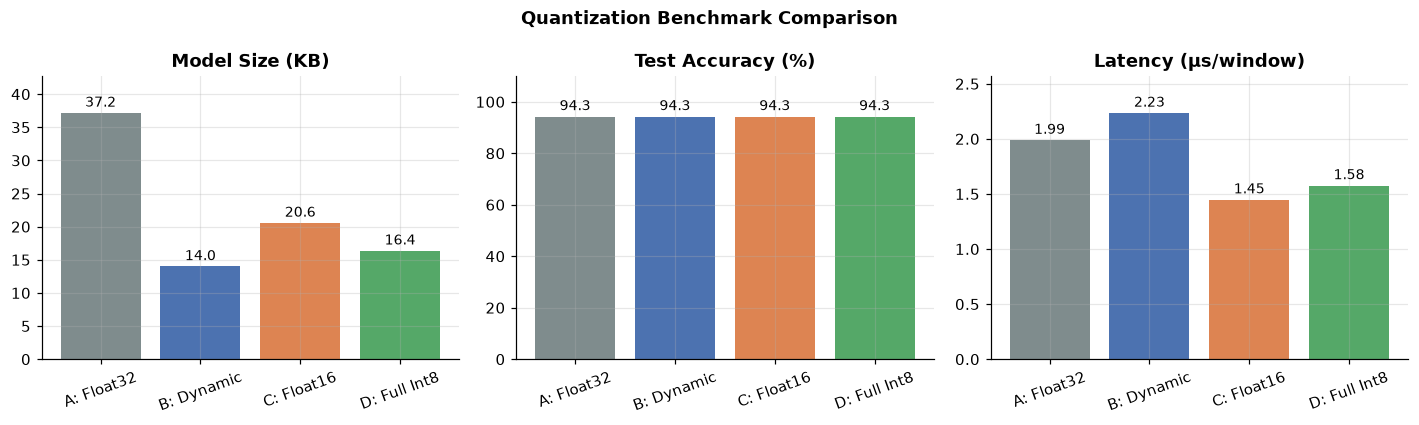

In [15]:
labels = ["A: Float32", "B: Dynamic", "C: Float16", "D: Full Int8"]
bar_colors = ["#7f8c8d", "#4C72B0", "#DD8452", "#55A868"]
metrics = [("Model Size (KB)", "Model Size (KB)", "{:.1f}"),
           ("Accuracy (%)", "Test Accuracy (%)", "{:.1f}"),
           ("Latency (µs/window)", "Latency (µs/window)", "{:.2f}")]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.9))
for ax, (col, title, fmt) in zip(axes, metrics):
    bars = ax.bar(labels, results[col], color=bar_colors)
    ax.bar_label(bars, labels=[fmt.format(v) for v in results[col]], padding=2, fontsize=9)
    ax.set_title(title, weight="bold")
    ax.tick_params(axis="x", rotation=20)
    ax.margins(y=0.15)
axes[1].set_ylim(0, 110)
fig.suptitle("Quantization Benchmark Comparison", weight="bold")
plt.tight_layout()
plt.show()

## 9. Analysis and Conclusion

### Key Observations
1. **Accuracy is preserved.** All four TFLite variants match the Keras baseline accuracy, so quantization caused no measurable loss for this model. The few errors are Sit-up windows classified as Walking, most likely from the slower phases between repetitions.
2. **Size.** Dynamic Range gives the largest reduction (about 62%), followed by Full Integer (about 56%) and Float16 (about 45%). None reaches the ideal 75% (int8) or 50% (float16), because the model is small (about 9,000 parameters) and fixed file overhead is a large share of each file. Dynamic Range only quantizes the large 128 × 64 layer, while Full Integer quantizes every layer but also stores 32-bit integer (int32) biases and scale and zero-point values for each tensor.
3. **Latency.** All variants run in about 2 µs per window on a laptop CPU. The int8 model is not faster here because desktop CPUs are highly optimized for float math and most of the time is interpreter overhead. On a microcontroller the int8 model would be the fastest.

### Why Full Integer Quantization Is Required for Microcontroller Deployment
1. **No floating-point hardware.** Many microcontrollers have no Floating Point Unit (FPU), or only a slow one. Int8 models run on integer math using optimized kernels such as Arm CMSIS-NN.
2. **Other schemes still compute in float.** Dynamic Range and Float16 models convert weights back to float32 at runtime, so they shrink on disk but still need float hardware and float-sized RAM.
3. **Lower RAM use.** Int8 activations need 4 times less RAM for intermediate results, and RAM is usually the tightest limit on a microcontroller.
4. **Accelerator support.** Low-power AI accelerators such as the Arm Ethos-U Neural Processing Unit (NPU) and Google Edge TPU (Tensor Processing Unit) only run fully int8 models.
5. **Energy.** Integer operations use less energy per inference, which matters for a battery-powered wearable.

**Conclusion:** Variant D (Full Integer) keeps the baseline accuracy while cutting model size by more than half, and it is the only variant that runs entirely on integer math. It is therefore the right choice for deployment on the wearable device.